# **Fundamentos de Aprendizaje por Refuerzo**
## ***Regresión Lineal Simple (Datos Exponenciales)***

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

## Importar data exponencial

In [ ]:
# Cargar el conjunto de datos
data = pd.read_csv(filepath_or_buffer='https://raw.githubusercontent.com/cdavid2804/test-1/main/data_exponencial.csv')
print(np.shape(data))
data.head(10)

(500, 2)


,x,y
0,3.000000,14.532162
1,3.004008,36.544822
2,3.008016,12.746624
3,3.012024,24.112946
4,3.016032,20.153364
5,3.020040,18.693223
6,3.024048,25.990807
7,3.028056,28.381486
8,3.032064,8.624307
9,3.036072,27.992558


## Graficar los datos

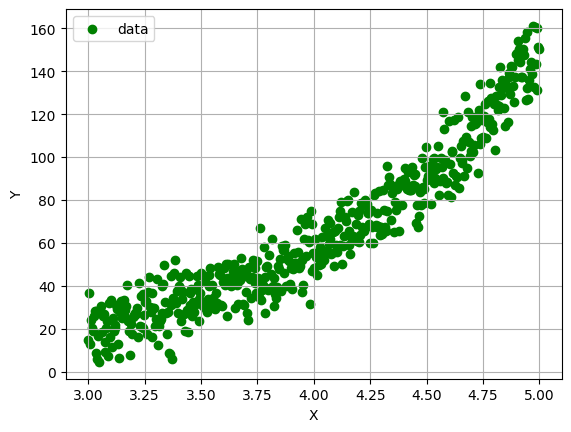

In [ ]:
datos = data.values
x = datos[:,0]
y = datos[:,1]
plt.scatter(x, y, c='green', label="data")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid()
plt.legend()

## Modelo de regresión

Sea:
$$ y = a_0e^{-b_0 x} $$

$$ ln(y) = ln(a_0 e^{-b_0 x}) $$

$$ ln(y) = ln(a_0) + ln(e^{-b_0 x}) $$

$$ ln(y) = ln(a_0) - b_0 x $$

Se puede aproximar lo anterior de la siguiente forma:

$$ Y =  A + BX $$

Donde:

$$Y=ln(y)$$

$$A = ln(a_0)$$

$$B=-b_0$$

## Linealizar la función

In [ ]:
Y = np.log(y)
X = x

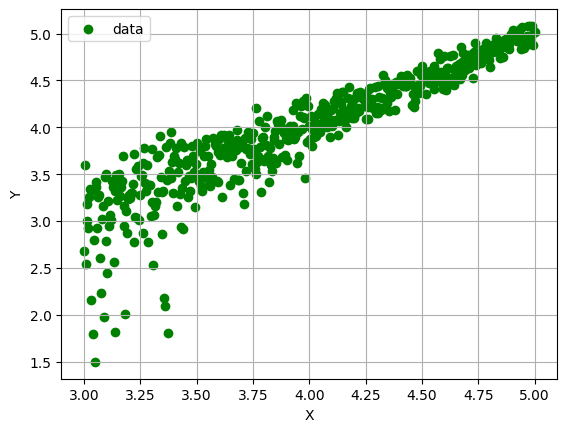

In [ ]:
plt.scatter(X, Y, c='green', label="data")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid()
plt.legend()

## Visualizar Data linealizada

## División de los datos

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2) #test_size es un porcentaje para datos de prueba (se coloca como decimal)
print(f"Training data: {np.shape(X_train)}")# imprime resultado de datos de entrenamiento
print(f"Test data: {np.shape(X_test)}")# imprime resultado de datos de prueba

Training data: (400,)
Test data: (100,)


## Modelo de regresión lineal

In [ ]:
def coeficientes(X, y):
  mean_X = sum(X) / len(X) #sum(X) calcula suma de datos dividido en len(X) cantidad de datos
  mean_y = sum(y) / len(y)
  SSxy = 0
  SSxx = 0
  for i in range(len(X)):
    SSxy += (X[i] - mean_X) * (y[i] - mean_y)
    SSxx += (X[i] - mean_X)**2

  beta_1 = SSxy / SSxx
  beta_0 = mean_y - (beta_1 * mean_X)

  return beta_0, beta_1

In [ ]:
A, B = coeficientes(X_train, y_train)
print(f"Coeficiente A: {A}")# A = beta_0
print(f"Coeficiente B: {B}")#B = beta_1


Coeficiente A: -0.15563474814994738
Coeficiente B: 1.0373122088671463


## Hacer predicciones

In [ ]:
#Data linealizada
y_preb = A + B * X_test
print(f"Salida predecida: {y_preb}")
print(f"Salida real: {y_test}")


Salida predecida: [4.33245555 3.46352468 3.76702685 3.82939031 4.63595772 3.34295533
 4.6733758  4.06221389 3.50510032 3.24317379 4.88125399 4.66506067
 4.80641784 4.86462374 4.04142607 4.41560683 3.50925789 3.17665277
 4.78563002 3.31800994 3.96658992 5.02261117 4.24098914 4.43639465
 3.66724532 3.83770544 3.86680839 4.12041979 4.0497412  4.60269721
 3.75871172 4.22435889 3.81691762 4.31582529 5.02676873 3.43442173
 3.88759621 3.12260444 3.16418008 4.86046617 4.12457735 3.89591133
 4.71495144 3.21407084 3.53420327 3.78781467 3.62982724 3.57577891
 3.7961298  3.01035021 4.2576194  3.86265082 4.57359426 3.69634826
 4.39481901 3.98737774 4.00816556 3.5425184  3.43026417 3.68387557
 3.74208147 3.13923469 4.54864888 4.17031056 4.84383592 3.79197223
 4.48212785 3.88343864 3.06855611 4.79394515 4.77315733 3.25564648
 4.28256478 4.02895338 4.27009209 3.71713608 3.04361072 3.06024098
 3.35127045 4.42807952 3.08518636 4.56527913 4.87709643 3.20159815
 4.20772863 3.76286929 4.04558364 3.29306456

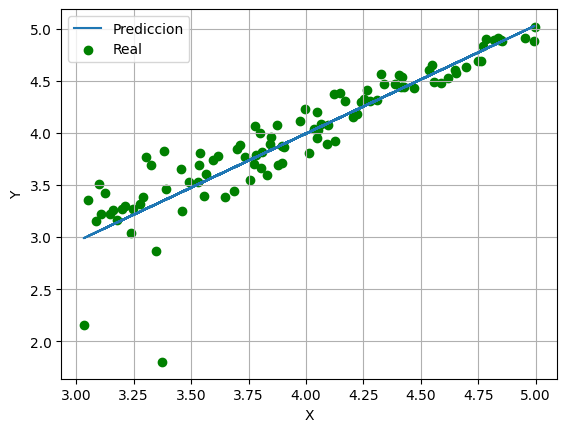

In [ ]:
plt.plot(X_test, y_preb, label="Prediccion")
plt.scatter(X_test, y_test, c = "green", label="Real")
plt.xlabel("X") #los puntos son los datos reales de prueba
plt.ylabel("Y") #linea recta se encuentran coeficientes A y B mayuscula linealizada
plt.grid()
plt.legend()

## Evaluación del modelo

In [ ]:
mse = np.mean((y_test - y_preb)**2)
rss = np.sum((y_test - y_preb)**2)
tts = np.sum((y_test - np.mean(y_test))**2)
r2 = 1 - (rss/tts)
print(f"Mean Square Error (MSE): {mse}")
print(f"Coeficiente R2: {r2}")

Mean Square Error (MSE): 0.05964427254248388
Coeficiente R2: 0.8334076539651074


## Modelo exponencial

In [ ]:
a0 = np.exp(A)
b0 = -B

print(f"a0: {a0}")
print(f"b0: {b0}")

y_preb_exp = a0 * np.exp(-b0 * x)

a0: 0.8558717420246911
b0: -1.0373122088671463


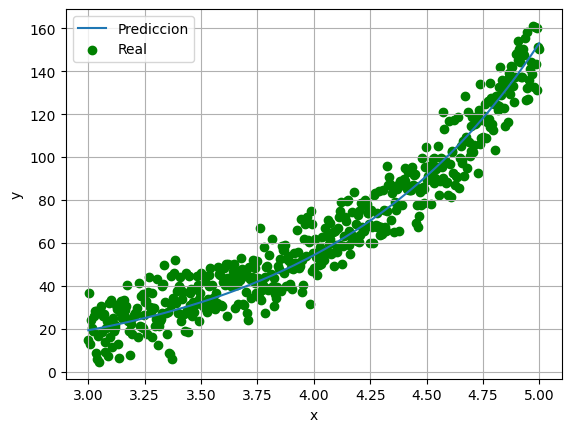

In [ ]:
plt.plot(x, y_preb_exp, label="Prediccion")
plt.scatter(x, y, c = "green", label="Real")
plt.xlabel("x") #los puntos son los datos reales de prueba
plt.ylabel("y") #linea recta se encuentran coeficientes A y B mayuscula linealizada
plt.grid()
plt.legend()